## Metabolite Identification


In [ ]:
#Imports and iterate to identify metabolites
!pip install ijson
import ijson
import pandas as pd

input_file = '/content/hmdb_metabolites_compact.json'
records = []
count = 0

with open(input_file, 'r') as f:
  # kvitems iterates over top-level dictionary: key=HMDB ID, value=metabolite dict
  for hmdb_id, metab in ijson.kvitems(f, ''):
    filtered = {'name': metab.get('name'), 'moldb_mono_mass': metab.get('moldb_mono_mass'), 'moldb_average_mass': metab.get('moldb_average_mass')}
    # Only keep metabolites with at least one mass value
    if filtered['moldb_mono_mass'] is not None or filtered['moldb_average_mass'] is not None:
      records.append(filtered)
      count += 1
      if count % 10000 == 0:
        print(f"{count} metabolites processed...")

# Convert to DataFrame
met_df = pd.DataFrame(records)
print(f"Finished! Total metabolites extracted: {len(met_df)}")

# Save to a smaller CSV
met_df.to_csv('/content/hmdb_metabolites_small.csv', index=False)
print("Saved small CSV: /content/hmdb_metabolites_small.csv")

10000 metabolites processed...
20000 metabolites processed...
30000 metabolites processed...
40000 metabolites processed...
50000 metabolites processed...
60000 metabolites processed...
70000 metabolites processed...
80000 metabolites processed...
90000 metabolites processed...
100000 metabolites processed...
110000 metabolites processed...
120000 metabolites processed...
130000 metabolites processed...
140000 metabolites processed...
150000 metabolites processed...
160000 metabolites processed...
170000 metabolites processed...
180000 metabolites processed...
190000 metabolites processed...
200000 metabolites processed...
Reached truncated end of JSON after 204505 metabolites. Last entry skipped.
Finished! Total metabolites extracted: 204505
Saved small CSV: /content/hmdb_metabolites_small.csv


In [ ]:
#sample of metabolite dataset
met_df = pd.read_csv("/content/hmdb_metabolites_small.csv")
met_df.head()

,name,moldb_mono_mass,moldb_average_mass
0,1-Methylhistidine,169.085127,169.1811
1,"1,3-Diaminopropane",74.084398,74.1249
2,2-Ketobutyric acid,102.031694,102.0886
3,2-Hydroxybutyric acid,104.047344,104.1050
4,2-Methoxyestrone,300.172545,300.3921


In [ ]:
# Adjust masses for positive ionization mode - mode used by Hong UCSD Dataset

# Mass of a proton
PROTON = 1.007276

# Create m/z columns for positive mode
met_df['moldb_mono_mz'] = met_df['moldb_mono_mass'] + PROTON
met_df['moldb_average_mz'] = met_df['moldb_average_mass'] + PROTON

In [ ]:
import numpy as np
from scipy.spatial import cKDTree

# Combine mono and average m/z into a 1D array
mass_array = np.concatenate([met_df['moldb_mono_mz'].values, met_df['moldb_average_mz'].values])
met_idx = np.concatenate([np.arange(len(met_df)), np.arange(len(met_df))])

# Build KDTree for fast nearest-neighbor search
tree = cKDTree(mass_array[:, None])

In [ ]:
#test file
df = pd.read_csv('/content/PHT_20_010_Cort_1200_top10.csv')
df.head()

,retention_time,mz,intensity
0,0.11,194.118,86651.70
1,0.11,232.929,83034.53
2,0.11,214.918,54967.86
3,0.11,241.069,54000.16
4,0.11,248.901,51665.10


In [ ]:
exp_file = '/content/PHT_20_010_Cort_1200_top10.csv'
exp_df = pd.read_csv(exp_file)

tolerance = 0.05  # Da, adjust based on instrument precision

matched_records = []

for mz, intensity in zip(exp_df['mz'], exp_df['intensity']):
  # Find metabolites within the tolerance
  idxs = tree.query_ball_point([mz], r=tolerance)
  for idx in idxs:
    matched_records.append({
        'metabolite_name': met_df['name'].iloc[met_idx[idx]],
        'experimental_file': exp_file,
        'm/z': mz,
        'intensity': intensity
    })

matched_df = pd.DataFrame(matched_records)
print(matched_df.head())

         metabolite_name                        experimental_file      m/z  \
0                Actarit  /content/PHT_20_010_Cort_1200_top10.csv  194.118   
1    n-benzoyl-d-alanine  /content/PHT_20_010_Cort_1200_top10.csv  194.118   
2             Betamipron  /content/PHT_20_010_Cort_1200_top10.csv  194.118   
3  N-Formylphenylalanine  /content/PHT_20_010_Cort_1200_top10.csv  194.118   
4  m-Methylhippuric acid  /content/PHT_20_010_Cort_1200_top10.csv  194.118   

   intensity  
0    86651.7  
1    86651.7  
2    86651.7  
3    86651.7  
4    86651.7  


In [ ]:
# Number of experimental peaks matched
print("Number of peaks matched to at least one metabolite:", matched_df['m/z'].nunique())

# Total number of matches (including multiple metabolites per peak)
print("Total matched rows (including duplicates):", len(matched_df))

Number of peaks matched to at least one metabolite: 7554
Total matched rows (including duplicates): 1405986


In [ ]:
#Specific metabolites in test csv
exp_df = pd.read_csv('/content/PHT_20_010_Cort_1200_top10.csv')
print("Total peaks in file:", len(exp_df))
print("Unique m/z values:", exp_df['mz'].nunique())
print("Peaks matched to at least one metabolite:", matched_df['m/z'].nunique())

Total peaks in file: 49226
Unique m/z values: 9379
Peaks matched to at least one metabolite: 7554


## Processing Metabolites


In [ ]:
#Imports
%%capture
!pip install pandas scipy
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
import glob
import os

In [ ]:
#Adjusting all masses in metabolite dataset due to proton ionization mode
met_file = '/content/hmdb_metabolites_small.csv'
met_df = pd.read_csv(met_file)

PROTON = 1.007276  # positive ion mode [M+H]+
met_df['moldb_mono_mz'] = met_df['moldb_mono_mass'] + PROTON
met_df['moldb_average_mz'] = met_df['moldb_average_mass'] + PROTON

# Build KDTree
mass_array = np.concatenate([met_df['moldb_mono_mz'].values, met_df['moldb_average_mz'].values])
met_idx = np.concatenate([np.arange(len(met_df)), np.arange(len(met_df))])
tree = cKDTree(mass_array[:, None])

In [ ]:
#importing UCSD data from 01_ucsd_dataset
depression_file = '/content/UCSD_depression_dataset.csv'
depression_df = pd.read_csv(depression_file)
depression_df.head()

,Unnamed: 0,index,file_name,diagnosis
0,0,134,PHT_20_010_Cort_1200.mzML,3
1,1,135,PHT_20_010_Cort_1600.mzML,3
2,2,136,PHT_20_010_Cort_1900.mzML,3
3,3,137,PHT_20_018_Cort_1000.mzML,0
4,4,138,PHT_20_018_Cort_1600.mzML,0


In [ ]:
#zipping up the map
depression_map = dict(zip(depression_df['file_name'], depression_df['diagnosis']))

In [ ]:
#Connecting google drive to get all the mass spec files but only printing top 20
!mkdir -p /content/raw_mass_spec
!cp -r "/content/drive/MyDrive/raw_mass_spec/"* /content/raw_mass_spec/
!ls /content/raw_mass_spec | head -20  # shows first 20 files

PHT_20_010_Cort_1200_top10.csv
PHT_20_010_Cort_1600_top10.csv
PHT_20_010_Cort_1900_top10.csv
PHT_20_018_Cort_1000_top10.csv
PHT_20_018_Cort_1600_top10.csv
PHT_20_018_Cort_1900_top10.csv
PHT_20_018_Cort_Waking_top10.csv
PHT_20_023_Cort_1000_top10.csv
PHT_20_023_Cort_1200_top10.csv
PHT_20_023_Cort_1600_top10.csv
PHT_20_023_Cort_1900_top10.csv
PHT_20_023_Cort_Waking_top10.csv
PHT_20_033_Cort_1000_top10.csv
PHT_20_033_Cort_1200_top10.csv
PHT_20_033_Cort_1600_top10.csv
PHT_20_033_Cort_1900_top10.csv
PHT_20_033_Cort_Waking_top10.csv
PHT_20_036_Cort_1000_top10.csv
PHT_20_036_Cort_1200_top10.csv
PHT_20_036_Cort_1600_top10.csv


In [ ]:
#setting parameters
data_folder = '/content/raw_mass_spec'
all_files = glob.glob(os.path.join(data_folder, '*.csv'))
tolerance = 0.05  # Da, can adjust for instrument

In [ ]:
#Creating output csv with all metabolites from each csv file
output_file = '/content/metabolites_wide_format.csv'

all_metabolites = set()
for i, file in enumerate(all_files, 1):
  print(f"Collecting metabolites from file {i}/{len(all_files)}: {os.path.basename(file)}")  # progress print
  exp_df = pd.read_csv(file, usecols=['mz'])
  idxs_list = tree.query_ball_point(exp_df['mz'].values[:, None], r=tolerance)
  for idxs in idxs_list:
    for idx in idxs:
      all_metabolites.add(met_df['name'].iloc[met_idx[idx]])
all_metabolites = sorted(all_metabolites)

print(f"Found {len(all_metabolites)} unique metabolites across all files.")

Found 204374 unique metabolites across all files.


In [ ]:
!pip install scipy pandas numpy
import numpy as np
import pandas as pd
import scipy.sparse as sp
import os

# map metabolite name → integer ID
metabolite_list = list(all_metabolites)
met_to_id = {m: i for i, m in enumerate(metabolite_list)}

num_mets = len(metabolite_list)
num_files = len(all_files)

print("Metabolites:", num_mets)
print("Files:", num_files)

Metabolites: 204374
Files: 274


In [ ]:
# (was for debugging - looks at current variables)
%whos

Variable          Type         Data/Info
----------------------------------------
PROTON            float        1.007276
all_files         list         n=274
cKDTree           type         <class 'scipy.spatial._ckdtree.cKDTree'>
cols              list         n=0
data              list         n=0
data_folder       str          /content/raw_mass_spec
depression_df     DataFrame         Unnamed: 0  index   <...>n\n[314 rows x 4 columns]
depression_file   str          /content/UCSD_depression_dataset.csv
depression_map    dict         n=314
glob              module       <module 'glob' from '/usr<...>/lib/python3.12/glob.py'>
last_heartbeat    float        1763264718.379947
mass_array        ndarray      409010: 409010 elems, type `float64`, 3272080 bytes (3.1204986572265625 Mb)
met_df            DataFrame                             <...>[204505 rows x 5 columns]
met_file          str          /content/hmdb_metabolites_small.csv
met_idx           ndarray      409010: 409010 elems, typ

In [ ]:
import numpy as np
from tqdm import tqdm

unique_metabolite_ids = set()

#Matching metabolites based on mz ratios
for file in tqdm(all_files, desc="Scanning patient files"):
  exp_df = pd.read_csv(file, usecols=['mz'])
  mz_values = exp_df['mz'].to_numpy()

  # Query KDTree in bulk (VERY FAST)
  results = tree.query_ball_point(mz_values.reshape(-1, 1), r=tolerance)

  # Flatten metabolite indices and add metabolite names
  for idx_list in results:
    for idx in idx_list:
      unique_metabolite_ids.add(met_idx[idx])

# Convert metabolite IDs to metabolite names
all_metabolites = sorted(met_df['name'].iloc[list(unique_metabolite_ids)].unique())

print("\nTotal matched metabolites:", len(all_metabolites))

Scanning patient files: 100%|██████████| 274/274 [06:55<00:00,  1.52s/it]



Total matched metabolites: 204374


In [ ]:
# Build a mapping from metabolite name → column index
metabolite_to_col = {name: i for i, name in enumerate(all_metabolites)}

# Build the correct mapping from original HMDB index → column index
orig_to_col = {}

for hmdb_idx in unique_metabolite_ids:
  name = met_df['name'].iloc[hmdb_idx]
  if name in metabolite_to_col:
    orig_to_col[hmdb_idx] = metabolite_to_col[name]

In [ ]:
#Ensuring nothing was lost in the process
num_metabolites = len(all_metabolites)

print("Number of metabolites (columns):", num_metabolites)
print("Mapping created: orig_to_col entries:", len(orig_to_col))

Number of metabolites (columns): 204374
Mapping created: orig_to_col entries: 204374


In [ ]:
# Recreate met_idx instantly
met_idx = np.concatenate([
    np.arange(len(met_df)),
    np.arange(len(met_df))
])

print(len(met_idx), mass_array.shape)

409010 (409010,)


In [ ]:
#Building wide matrix for all csv files
wide_rows = []
file_names = []
depression_status_list = []

for file in tqdm(all_files, desc="Building wide matrix rows"):
  df = pd.read_csv(file, usecols=['mz', 'intensity'])
  mz_values = df['mz'].to_numpy()
  intensities = df['intensity'].to_numpy()

  # Query all M/Z at once
  results = tree.query_ball_point(mz_values.reshape(-1, 1), r=tolerance)

  # Build dict: original_metabolite_index -> max intensity
  metabolite_intensity = {}

  for peak_i, idx_list in enumerate(results):
    if idx_list:
      inten = intensities[peak_i]
      for idx_raw in idx_list:
        hmdb_idx = met_idx[idx_raw]  # original HMDB index
        old = metabolite_intensity.get(hmdb_idx, 0)
        if inten > old:
          metabolite_intensity[hmdb_idx] = inten

    # Create one row of full length
    row = np.zeros(num_metabolites, dtype=np.float32)

    for hmdb_idx, value in metabolite_intensity.items():
      if hmdb_idx in orig_to_col:
        col = orig_to_col[hmdb_idx]
        row[col] = value

    wide_rows.append(row)

    base_name = os.path.basename(file)
    file_names.append(base_name)
    depression_status_list.append(depression_map.get(base_name, np.nan))

Building wide matrix rows: 100%|██████████| 274/274 [10:13<00:00,  2.24s/it]


In [ ]:
print(depression_map)

{'PHT_20_010_Cort_1200.mzML': 3, 'PHT_20_010_Cort_1600.mzML': 3, 'PHT_20_010_Cort_1900.mzML': 3, 'PHT_20_018_Cort_1000.mzML': 0, 'PHT_20_018_Cort_1600.mzML': 0, 'PHT_20_018_Cort_1900.mzML': 0, 'PHT_20_018_Cort_Waking.mzML': 0, 'PHT_20_023_Cort_1000.mzML': 0, 'PHT_20_023_Cort_1200.mzML': 0, 'PHT_20_023_Cort_1600.mzML': 0, 'PHT_20_023_Cort_1900.mzML': 0, 'PHT_20_023_Cort_Waking.mzML': 0, 'PHT_20_033_Cort_1000.mzML': 0, 'PHT_20_033_Cort_1200.mzML': 0, 'PHT_20_033_Cort_1600.mzML': 0, 'PHT_20_033_Cort_1900.mzML': 0, 'PHT_20_033_Cort_Waking.mzML': 0, 'PHT_20_036_Cort_1000.mzML': 0, 'PHT_20_036_Cort_1200.mzML': 0, 'PHT_20_036_Cort_1600.mzML': 0, 'PHT_20_036_Cort_1900.mzML': 0, 'PHT_20_036_Cort_Waking.mzML': 0, 'PHT_20_038_Cort_1000.mzML': 0, 'PHT_20_038_Cort_1200.mzML': 0, 'PHT_20_038_Cort_1600.mzML': 0, 'PHT_20_038_Cort_1900.mzML': 0, 'PHT_20_038_Cort_Waking.mzML': 0, 'PHT_20_041_Cort_1000.mzML': 3, 'PHT_20_041_Cort_1200.mzML': 3, 'PHT_20_041_Cort_1600.mzML': 3, 'PHT_20_041_Cort_1900.mzML': 

In [ ]:
# Build depression_status_list with proper mapping
depression_status_list = []

for file in all_files:
    base_name = os.path.basename(file)  #PHT_20_128_Cort_1000_top10.csv

    # Convert to the format in depression_map
    key_name = base_name.replace('_top10.csv', '.mzML')  #PHT_20_128_Cort_1000.mzML

    if key_name in depression_map:
        status = depression_map[key_name]
    else:
        print(f"Warning: {key_name} not found in depression_map! Assigning NaN.")
        status = np.nan
    depression_status_list.append(status)

In [ ]:
#Filter all_files to only those with a depression label
filtered_files = []

for file in all_files:
  base_name = os.path.basename(file)
  key_name = base_name.replace('_top10.csv', '.mzML')
  if key_name in depression_map:
    filtered_files.append(file)
  else:
    print(f"Skipping {base_name} — no matching depression label.")

all_files = filtered_files
print(f"{len(all_files)} files will be processed after filtering.")

Skipping PHT_20_098_Cort_1600_top10.csv — no matching depression label.
Skipping PHT_20_088_Cort_1000_top10.csv — no matching depression label.
Skipping PHT_20_098_Cort_1900_top10.csv — no matching depression label.
Skipping PHT_20_098_Cort_1200_top10.csv — no matching depression label.
Skipping PHT_20_098_Cort_Waking_top10.csv — no matching depression label.
269 files will be processed after filtering.


In [ ]:
#Build depression_status_list and file_names for filtered files
depression_status_list = []
file_names = []

for file in all_files:
  base_name = os.path.basename(file)
  key_name = base_name.replace('_top10.csv', '.mzML')
  depression_status_list.append(depression_map[key_name])
  file_names.append(base_name)

In [ ]:
# Find indices of valid files
valid_indices = []
for i, file in enumerate(all_files):
    base_name = os.path.basename(file)
    key_name = base_name.replace('_top10.csv', '.mzML')
    if key_name in depression_map:
        valid_indices.append(i)

# Filter wide_rows to only valid files
wide_rows_filtered = [wide_rows[i] for i in valid_indices]

# Build final DataFrame
wide_df = pd.DataFrame(wide_rows_filtered, columns=all_metabolites)
wide_df.insert(0, 'depression_status', [depression_map[os.path.basename(all_files[i]).replace('_top10.csv','.mzML')] for i in valid_indices])
wide_df.insert(1, 'file_name', [os.path.basename(all_files[i]) for i in valid_indices])

print("Wide matrix shape:", wide_df.shape)

Wide matrix shape: (269, 204376)


In [ ]:
wide_df.head()

,depression_status,file_name,"((1R,2R,5R)-2-(2,6-Dimethoxy-4-(2-methyloctan-2-yl)phenyl)-7,7-dimethyl-4-bicyclo(3.1.1)hept-3-enyl) methanol","((2,6-Bis(1-methylethyl)phenoxy)sulfonyl)carbamic acid 2,6-bis(1-methylethyl)phenyl ester",((2-Amino-3-((2-amino-3-((carboxymethyl)amino)-3-oxopropyl)dithio)propanoyl)amino)acetic acid,"((2R,3S)-3-Amino-2-hydroxy-2-(1H-imidazol-4-ylmethyl)-5-methyl)-5-methylhexanoic Acid","((2R,3S,4S,5R,6S)-6-(2-(3-(Benzofuran-5-yl)propanoyl)-3-hydroxy-5-methylphenoxy)-3,4,5-trihydroxytetrahydro-2H-pyran-2-yl)methyl methyl carbonate","((2R,5R)-2-Benzyl-5-(prop-2-yn-1-yloxy)piperidin-1-yl)(4-(bis(4-fluorophenyl)(hydroxy)methyl)-2H-1,2,3-triazol-2-yl)methanone","((4-(3-(4-Fluoro-alpha-hydroxybenzyl)-4-hydroxyphenoxy)-3,5-dimethylphenyl)amino)oxoacetate",((4-(4-Amidinophenoxy)butanoyl)aspartyl)valine,...,"{3,5-Dichloro-4-[4-Hydroxy-3-(Propan-2-Yl)phenoxy]phenyl}acetic Acid","{4-[({2-[3-Fluoro-4-(Trifluoromethyl)phenyl]-4-Methyl-1,3-Thiazol-5-Yl}methyl)sulfanyl]-2-Methylphenoxy}acetic Acid",{4-[2-Acetylamino-2-(1-biphenyl-4-ylmethyl-2-oxo-azepan-3-ylcarbamoyl)-ethyl]-2-phosphono-phenoxy}-acetic acid,"{4-[4-(6-Carbamoyl-3,5-dimethylpyrazin-2-yl)phenyl]cyclohexyl}acetic acid","{[5-(5-Nitro-2-furyl)-1,3,4-oxadiazol-2-YL]thio}acetic acid",Α-chaconine,α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,β-L-IdoA-(1→4)-α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,β-L-IdoA2S-(1→4)-α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,﻿Bosutinib
0,1,PHT_20_128_Cort_1000_top10.csv,2.090140e+04,94456.437500,24006.970703,2.539550e+04,0.0,7.747589e+06,0.000000,57966972.0,...,1.709097e+07,0.0,0.000000,1880.219971,7.269436e+04,1724.439941,0.0,0.0,1543.719971,170449.281250
1,4,PHT_20_129_Cort_1000_top10.csv,7.653516e+05,1985.589966,13872.980469,6.723522e+04,0.0,0.000000e+00,1539.339966,50792656.0,...,1.387298e+04,0.0,1520.869995,1628.630005,1.517768e+06,0.000000,0.0,0.0,0.000000,1588.030029
2,3,PHT_20_127_Cort_1900_top10.csv,4.900854e+04,26955.150391,43092.980469,8.996620e+03,0.0,1.125140e+07,1836.060059,58654140.0,...,5.322293e+07,0.0,1707.510010,38062.539062,2.491092e+07,0.000000,0.0,0.0,0.000000,168857.593750
3,0,PHT_20_090_Cort_1900_top10.csv,9.154094e+06,67767.812500,13533.570312,6.232470e+04,0.0,2.276378e+04,0.000000,32385108.0,...,1.353357e+04,0.0,0.000000,1575.859985,2.093046e+06,0.000000,0.0,0.0,0.000000,0.000000
4,1,PHT_20_101_Cort_1000_top10.csv,5.844667e+04,0.000000,8335.240234,5.998930e+07,0.0,0.000000e+00,0.000000,31706448.0,...,8.335240e+03,0.0,0.000000,20067.070312,2.243427e+04,0.000000,0.0,0.0,0.000000,1866.709961


In [ ]:
#had to use parquet because csv not efficient
wide_df.to_parquet('/content/wide_metabolites.parquet')

##Unsupervised Analysis

In [ ]:
#starting from parquet
import pandas as pd

df = pd.read_parquet('/content/wide_metabolites.parquet')
pd.set_option('display.max_columns', 50)
df

,depression_status,file_name,"((1R,2R,5R)-2-(2,6-Dimethoxy-4-(2-methyloctan-2-yl)phenyl)-7,7-dimethyl-4-bicyclo(3.1.1)hept-3-enyl) methanol","((2,6-Bis(1-methylethyl)phenoxy)sulfonyl)carbamic acid 2,6-bis(1-methylethyl)phenyl ester",((2-Amino-3-((2-amino-3-((carboxymethyl)amino)-3-oxopropyl)dithio)propanoyl)amino)acetic acid,"((2R,3S)-3-Amino-2-hydroxy-2-(1H-imidazol-4-ylmethyl)-5-methyl)-5-methylhexanoic Acid","((2R,3S,4S,5R,6S)-6-(2-(3-(Benzofuran-5-yl)propanoyl)-3-hydroxy-5-methylphenoxy)-3,4,5-trihydroxytetrahydro-2H-pyran-2-yl)methyl methyl carbonate","((2R,5R)-2-Benzyl-5-(prop-2-yn-1-yloxy)piperidin-1-yl)(4-(bis(4-fluorophenyl)(hydroxy)methyl)-2H-1,2,3-triazol-2-yl)methanone","((4-(3-(4-Fluoro-alpha-hydroxybenzyl)-4-hydroxyphenoxy)-3,5-dimethylphenyl)amino)oxoacetate",((4-(4-Amidinophenoxy)butanoyl)aspartyl)valine,"(+)-(1R,2R)-1,2-Diphenylethane-1,2-diol","(+)-(R)-2-(2,4-Difluorophenyl)-1-(3-((E)-4-(2,2,3,3-tetrafluoropropoxy)styryl)-1,2,4-triazol-1-yl)-3-(1,2,4-triazol-1-yl)propan-2-ol","(+)-1(10),4-Cadinadiene","(+)-1(9),10-Pacifigorgiadiene","(+)-1,18-Nonacosanediol",(+)-1-(9-Fluorenyl)ethyl chloroformate,(+)-1-Methylpropyl 3-(methylthio)-2-propenyl disulfide,(+)-11-Hydroxy-9-triacontanone,(+)-12a-Hydroxypachyrrhizone,"(+)-15,16-Dihydroxyoctadecanoic acid","(+)-2,3-Dihydro-3-methyl-1H-pyrrole","(+)-2-(Benzothiophen-4-yl)-N-methyl-N-((1R,2R)-2-pyrrolidin-1-ylcyclohexyl)acetamide",(+)-2-Amino-7-phosphonoheptanoic acid,"(+)-3,4-Didehydrocoronaridine","(+)-3-(3,4-Methylenedioxyphenyl)-1,2-propanediol",...,xi-p-Menth-3-en-1-ol,xi-p-Menth-3-ene,"xi-p-Mentha-1(7),2-dien-4-ol","xi-p-Mentha-3,8-dien-1-ol","y,y-Carotene, 7,7',8,8',11,12-hexahydro-, cis-(9CI)",y-Morphine,z-Clausenamide,z-phe-arg-7-amido-4-methylcoumarin,z2-Tocopherol,zaltoprofen,zeta-Carotene epoxide,zotepine,{1-[2-(4-Carbamimidoyl-benzoylamino)-propionyl]-piperidin-4-yloxy}-acetic acid,"{2,6-dihydroxy-4-[4-hydroxy-7-(hydroxymethyl)-11-oxo-2,8-dioxatricyclo[7.3.1.0⁵,¹³]trideca-1(12),3,5(13),6,9-pentaen-3-yl]phenoxy}dihydroxyoxo-λ⁶-sulfanylium",{2-methoxy-4-[(5-oxooxolan-2-yl)methyl]phenyl}oxidanesulfonic acid,"{3,5-Dichloro-4-[4-Hydroxy-3-(Propan-2-Yl)phenoxy]phenyl}acetic Acid","{4-[({2-[3-Fluoro-4-(Trifluoromethyl)phenyl]-4-Methyl-1,3-Thiazol-5-Yl}methyl)sulfanyl]-2-Methylphenoxy}acetic Acid",{4-[2-Acetylamino-2-(1-biphenyl-4-ylmethyl-2-oxo-azepan-3-ylcarbamoyl)-ethyl]-2-phosphono-phenoxy}-acetic acid,"{4-[4-(6-Carbamoyl-3,5-dimethylpyrazin-2-yl)phenyl]cyclohexyl}acetic acid","{[5-(5-Nitro-2-furyl)-1,3,4-oxadiazol-2-YL]thio}acetic acid",Α-chaconine,α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,β-L-IdoA-(1→4)-α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,β-L-IdoA2S-(1→4)-α-D-GlcNAc3S-(1→4)-β-D-GlcA(1→3)-β-D-Gal(1→3)-β-D-Gal(1→4)-D-Xyl,﻿Bosutinib
0,1,PHT_20_128_Cort_1000_top10.csv,2.090140e+04,94456.437500,24006.970703,2.539550e+04,0.0,7.747589e+06,0.000000,57966972.0,4.387622e+04,0.000000,2090.239990,2090.239990,1112.130005,1734.060059,39684.570312,1579.550049,0.000000e+00,1527.839966,5.717034e+06,4.404202e+06,5.001954e+06,1.980429e+04,1.173519e+06,...,83203.070312,1.981029e+06,5.756638e+06,5.756638e+06,0.000000,1.354576e+06,1.053298e+07,492775.406250,6166.479980,27571.019531,2396.360107,1.676630e+03,1.241235e+04,1561.239990,3.427275e+04,1.709097e+07,0.0,0.000000,1880.219971,7.269436e+04,1.724440e+03,0.000000,0.000000,1543.719971,170449.281250
1,4,PHT_20_129_Cort_1000_top10.csv,7.653516e+05,1985.589966,13872.980469,6.723522e+04,0.0,0.000000e+00,1539.339966,50792656.0,1.140495e+06,1332.339966,7869.439941,7869.439941,0.000000,16503.830078,36010.621094,0.000000,1.990300e+03,1307.670044,3.643064e+05,4.883298e+06,2.442452e+06,2.584269e+04,1.853018e+06,...,50056.988281,8.829171e+04,2.322954e+06,2.322954e+06,0.000000,8.557422e+05,2.054028e+07,0.000000,1951.969971,18522.740234,0.000000,1.995464e+06,4.520396e+04,21926.230469,2.785551e+04,1.387298e+04,0.0,1520.869995,1628.630005,1.517768e+06,0.000000e+00,0.000000,0.000000,0.000000,15

In [ ]:
#imports
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, zscore
import matplotlib.pyplot as plt
import seaborn as sns

#Spearman Correlation
depression = df['depression_status']
metabolites = df.drop(columns=['depression_status', 'file_name']).select_dtypes(include=[np.number])

print("Number of metabolites:", metabolites.shape[1])

metabolites = metabolites.loc[:, metabolites.nunique() > 1].dropna(axis=1, how='all')
print("Number of metabolites after filtering:", metabolites.shape[1])

corrs = []
pvals = []

for col in metabolites.columns:
    rho, p = spearmanr(depression, metabolites[col])
    corrs.append(rho)
    pvals.append(p)

results = pd.DataFrame({
    "metabolite": metabolites.columns,
    "spearman_rho": corrs,
    "p_value": pvals
})

results_sorted = results.sort_values(by='spearman_rho', ascending=False)

results_sorted = results_sorted.drop_duplicates(subset='spearman_rho', keep='first')

top_positive = results_sorted.head(7).iloc[2:]   # drop first two
top_negative = results_sorted.tail(5)

print("Top positive metabolites:\n", top_positive)
print("\nTop negative metabolites:\n", top_negative)

metabolites_scaled = metabolites.apply(zscore)

# Get metabolite names as lists (strings)
top_positive_names = top_positive['metabolite'].tolist()
top_negative_names = top_negative['metabolite'].tolist()

# Filter: keep only metabolites that exist in the data
top_positive_names = [m for m in top_positive_names if m in metabolites_scaled.columns]
top_negative_names = [m for m in top_negative_names if m in metabolites_scaled.columns]

print("\nUsable positive metabolites:", top_positive_names)
print("Usable negative metabolites:", top_negative_names)

def mean_by_depression(met_list):
    return metabolites_scaled[met_list].groupby(depression).mean()

pos_means = mean_by_depression(top_positive_names)
neg_means = mean_by_depression(top_negative_names)

print("\npos_means table:")
print(pos_means)

print("\nneg_means table:")
print(neg_means)

Number of metabolites: 204374
Number of metabolites after filtering: 204369
Top positive metabolites:
                                             metabolite  spearman_rho   p_value
137646                            PE(24:1(15Z)/P-18:0)      0.193169  0.001455
144136  PG(i-15:0/20:5(7Z,9Z,11E,13E,17Z)-3OH(5,6,15))      0.193168  0.001455
166424                              TG(15:0/14:0/15:0)      0.191543  0.001598
151516                          PIP(18:1(9Z)/16:1(9Z))      0.191392  0.001612
150342                          PI(22:2(13Z,16Z)/LTE4)      0.190097  0.001737

Top negative metabolites:
                            metabolite  spearman_rho   p_value
106804            DG(15:0/0:0/22:5n6)     -0.191812  0.001574
115208            Hydroxypioglitazone     -0.195894  0.001241
154724  PS(18:3(9Z,12Z,15Z)/16:1(9Z))     -0.207513  0.000615
154804   PS(18:4(6Z,9Z,12Z,15Z)/16:0)     -0.220199  0.000273
112291           Erucylphosphocholine     -0.225547  0.000191

Usable positive metabo

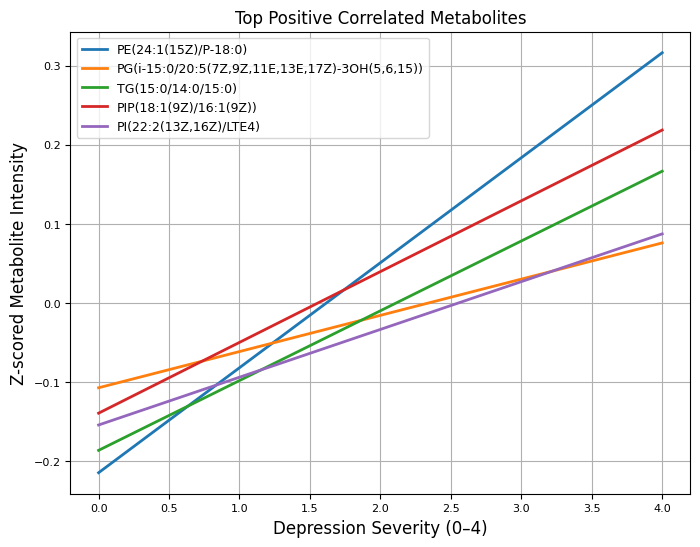

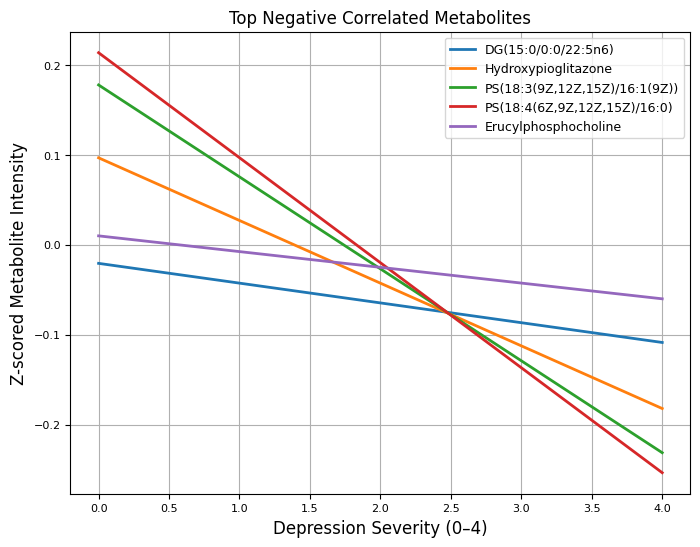

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from sklearn.linear_model import LinearRegression

#plot spearman correlation
def plot_best_fit(means_df, title):
  plt.figure(figsize=(8,6))
  x = means_df.index.values.reshape(-1,1)
  for met in means_df.columns:
    y = means_df[met].values
    model = LinearRegression().fit(x, y)
    y_fit = model.predict(x)
    plt.plot(x, y_fit, label=met, linewidth=2)
  plt.xlabel("Depression Severity (0–4)", fontsize=12)
  plt.ylabel("Z-scored Metabolite Intensity", fontsize=12)
  plt.title(title, fontsize=12)
  plt.legend(fontsize=9)
  plt.grid(True)
  plt.tick_params(axis='both', which='major', labelsize=8)
  plt.show()

plot_best_fit(pos_means, "Top Positive Correlated Metabolites")
plot_best_fit(neg_means, "Top Negative Correlated Metabolites")

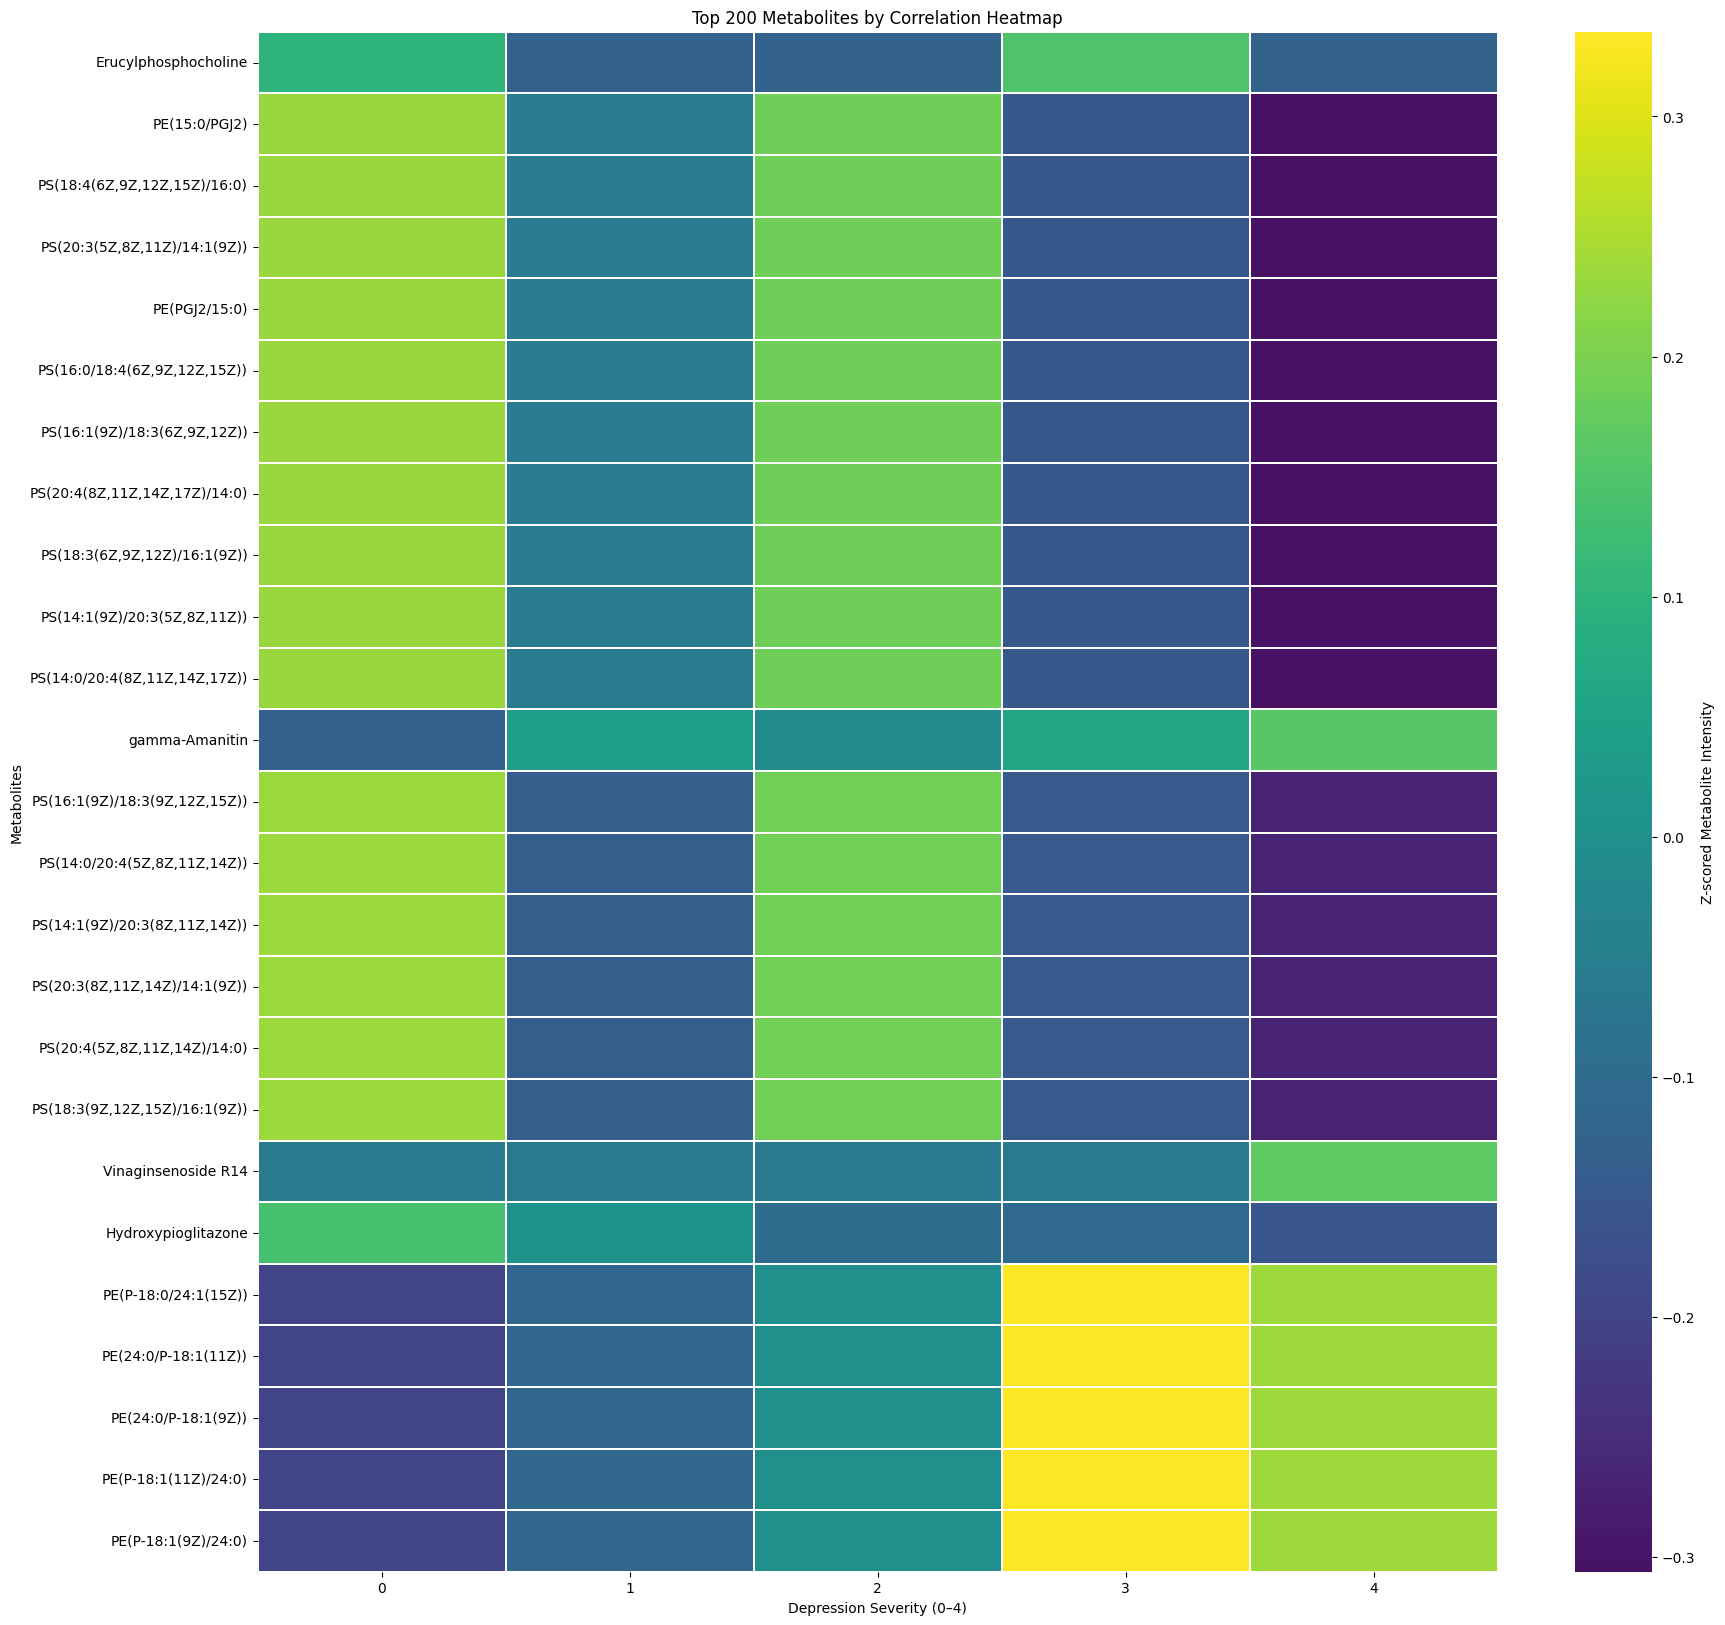

In [ ]:
# Take top 200 absolute correlations
results['abs_rho'] = results['spearman_rho'].abs()
top_metabs = results.sort_values('abs_rho', ascending=False).head(25)['metabolite']

heatmap_data = metabolites[top_metabs].apply(zscore).groupby(depression).mean().T

plt.figure(figsize=(20, 20))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    center=0,
    cbar_kws={'label': 'Z-scored Metabolite Intensity'},
    linewidths=0.1
)
plt.xlabel("Depression Severity (0–4)")
plt.ylabel("Metabolites")
plt.title("Top 200 Metabolites by Correlation Heatmap")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


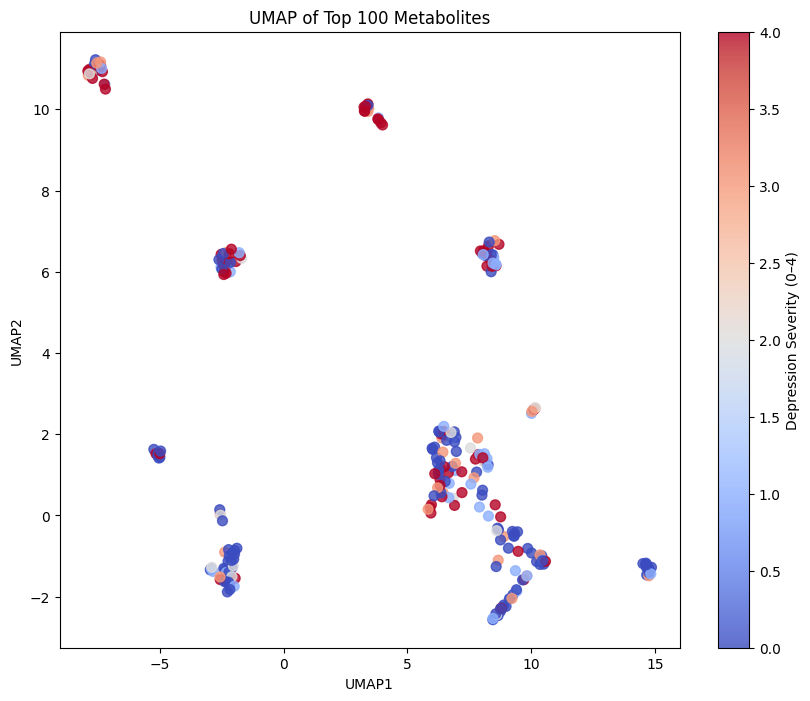

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


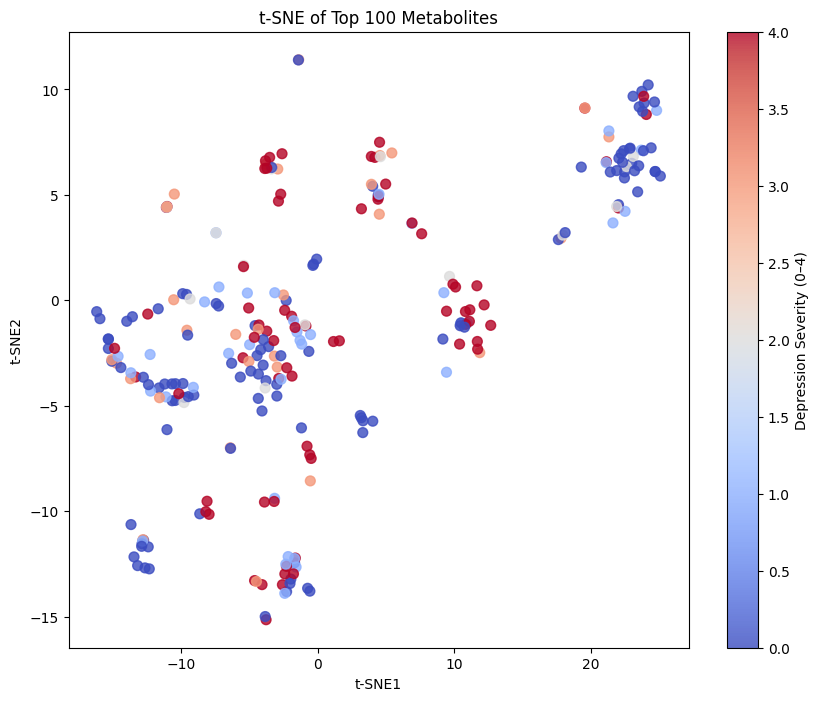

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
!pip install umap-learn
import umap
from sklearn.manifold import TSNE

# Select top 100 metabolites by absolute correlation
results['abs_rho'] = results['spearman_rho'].abs()
top_metabs = results.sort_values('abs_rho', ascending=False).head(100)['metabolite'].tolist()

X = metabolites[top_metabs]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Plot UMAP
plt.figure(figsize=(10,8))
plt.scatter(X_umap[:,0], X_umap[:,1], c=depression.values, cmap='coolwarm', s=50, alpha=0.8)
plt.colorbar(label='Depression Severity (0–4)')
plt.title('UMAP of Top 100 Metabolites')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

# Apply t-SNE
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne_model.fit_transform(X_scaled)

# Plot t-SNE
plt.figure(figsize=(10,8))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=depression.values, cmap='coolwarm', s=50, alpha=0.8)
plt.colorbar(label='Depression Severity (0–4)')
plt.title('t-SNE of Top 100 Metabolites')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.show()

In [ ]:
#DBSCAN - unsupervised clustering
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Select top 100 metabolites by absolute correlation
results['abs_rho'] = results['spearman_rho'].abs()
top_metabs = results.sort_values('abs_rho', ascending=False).head(5000)['metabolite'].tolist()

X = metabolites[top_metabs]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
db = DBSCAN()
db = db.fit_predict(X_scaled)
print(db)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1]


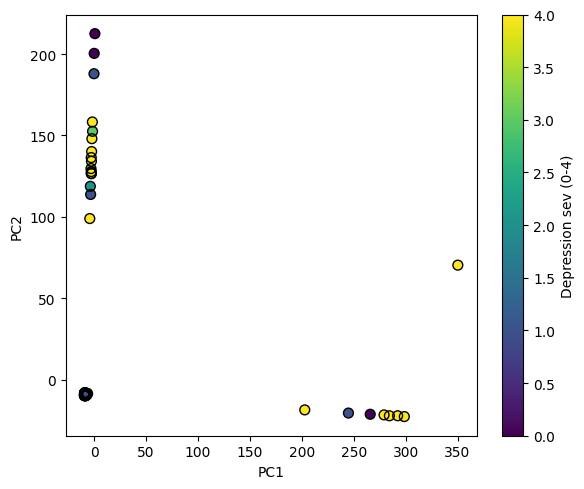

In [ ]:
#plot DB Scan using PCA
from sklearn.decomposition import PCA
dep = depression.values

db = DBSCAN(eps=0.5, min_samples=5)
db = db.fit_predict(X_scaled)

X2 = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6,5))
scatter = plt.scatter(X2[:,0], X2[:,1], c=dep, cmap='viridis')

for cluster_id in set(db):
    mask = db == cluster_id
    plt.scatter(X2[mask,0], X2[mask,1], facecolors='none', edgecolors='black', s=50)

cbar = plt.colorbar(scatter)
cbar.set_label("Depression sev (0-4)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

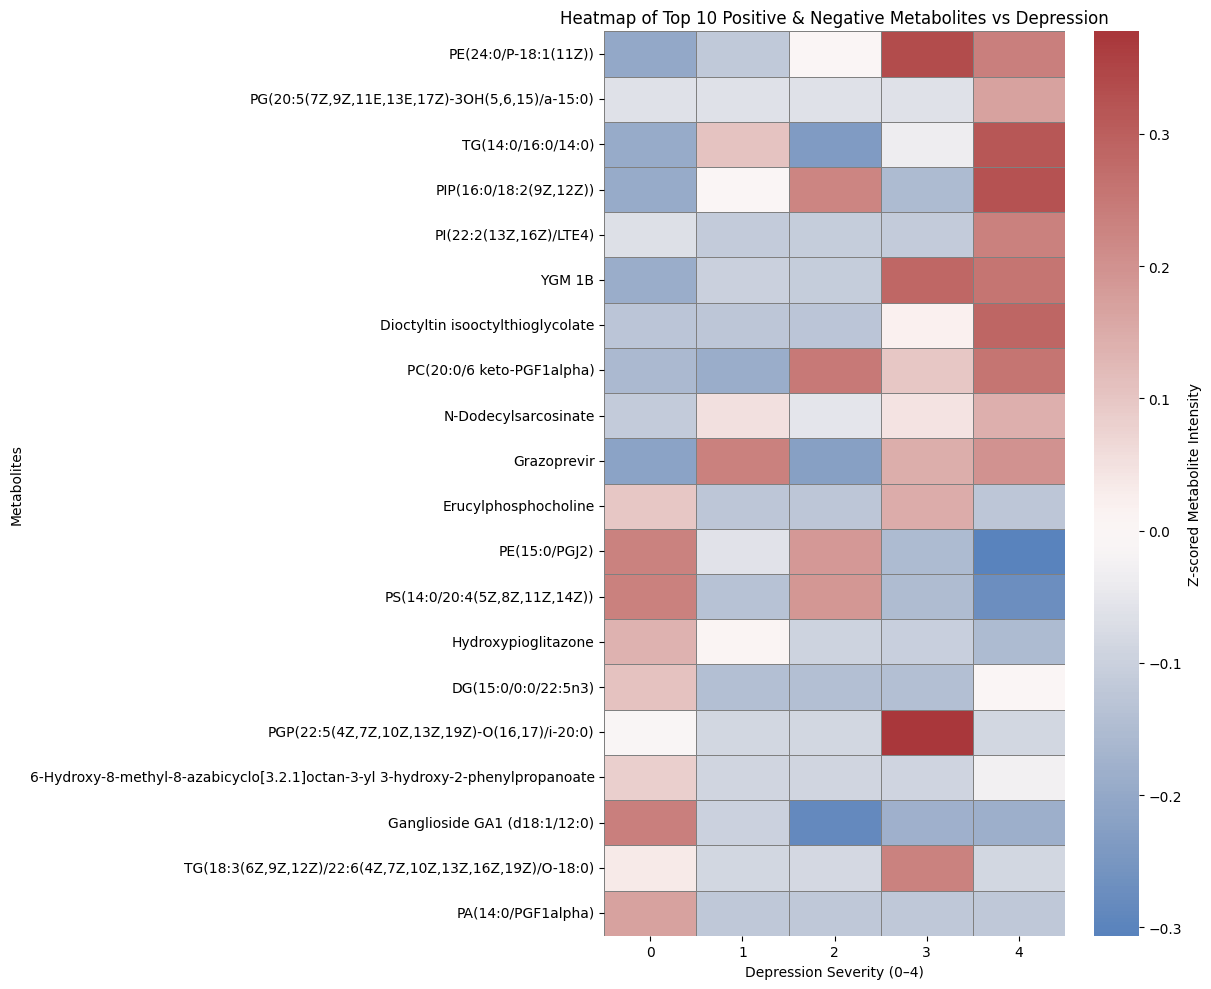

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

#Plot heatmap based on spearman correlation

results_unique = results.drop_duplicates(subset='spearman_rho', keep='first')

top_positive = results_unique[results_unique['spearman_rho'] > 0].sort_values(['spearman_rho', 'p_value'], ascending=[False, True]).iloc[2:].head(10)

top_negative = results_unique[results_unique['spearman_rho'] < 0].sort_values(['spearman_rho', 'p_value'], ascending=[True, True]).head(10)

top_metabolites = pd.concat([top_positive, top_negative])['metabolite'].tolist()

metabolites_scaled = metabolites[top_metabolites].apply(zscore)

heatmap_data = metabolites_scaled.groupby(depression).mean().T

plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_data,
    cmap='vlag',
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Z-scored Metabolite Intensity'}
)
plt.xlabel("Depression Severity (0–4)")
plt.ylabel("Metabolites")
plt.title("Heatmap of Top 10 Positive & Negative Metabolites vs Depression")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

#Builds a feature x severity matrix of mean intensities.
#Optionally z-scores each feature across severity levels (like your plot).
#Exports long + wide formats.

def export_feature_by_severity_heatmap_matrix(X: pd.DataFrame, severity: pd.Series, features: list, out_csv: str, zscore_across_severity: bool = True):
  sev = pd.Series(severity).astype(int)
  Xsub = X[features].copy()

  # mean per severity level
  mat = Xsub.groupby(sev).mean().T  # rows=features, cols=severity

  if zscore_across_severity:
    mat = (mat - mat.mean(axis=1).values[:, None]) / (mat.std(axis=1).replace(0, np.nan).values[:, None])

  mat.to_csv(out_csv, index=True)  # wide format: row=feature, columns=severity
  return mat

In [ ]:
# Example: pick top features
top_features = list(X.columns[:20])  # my selected metabolites
heatmap_matrix = export_feature_by_severity_heatmap_matrix(
    X=X,
    severity=y,
    features=top_features,
    out_csv="heatmap_matrix_zscored.csv",
    zscore_across_severity=True
)
print(heatmap_matrix.head())

depression_status                    0         1
Erucylphosphocholine          0.707107 -0.707107
PE(15:0/PGJ2)                 0.707107 -0.707107
PS(18:4(6Z,9Z,12Z,15Z)/16:0)  0.707107 -0.707107
PS(20:3(5Z,8Z,11Z)/14:1(9Z))  0.707107 -0.707107
PE(PGJ2/15:0)                 0.707107 -0.707107


###Spearmen Dataset Creation

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

#importing/processing parquet
df = pd.read_parquet("/content/wide_metabolites.parquet")
depression = df["depression_status"]

metabolites = df.drop(columns=["depression_status", "file_name"])
metabolites = metabolites.loc[:, metabolites.nunique() > 1].dropna(axis=1, how="all")
print("Metabolites available:", metabolites.shape[1])

In [ ]:
#computing spearmen
corrs = []
pvals = []
names = []

for col in metabolites.columns:
    rho, p = spearmanr(depression, metabolites[col])
    corrs.append(rho)
    pvals.append(p)
    names.append(col)

results = pd.DataFrame({
    "metabolite": names,
    "spearman_rho": corrs,
    "p_value": pvals
})

In [ ]:
#using spearman values for dataset
results = results.drop_duplicates(subset="spearman_rho", keep="first")
results_sorted = results.reindex(results["spearman_rho"].abs().sort_values(ascending=False).index)
top200 = results_sorted.head(250)
top200 = top200.drop(index=[203828, 202735])

In [ ]:
#Using only top 200 spearman ranked metabolites to create spearman.csv (parquet too big)
top200_names = top200["metabolite"].tolist()
filtered_df = df[["depression_status", "file_name"] + top200_names]
print("Final filtered dataset shape:", filtered_df.shape)
filtered_df.to_csv("spearman.csv", index=False)

##Supervised ML Analysis

###Pre-processing

In [ ]:
#importing spearman dataset
import pandas as pd
import numpy as np
r_df = pd.read_csv('/content/spearman.csv')
r_df.head()

,depression_status,file_name,Erucylphosphocholine,PE(15:0/PGJ2),"PS(14:0/20:4(5Z,8Z,11Z,14Z))",Hydroxypioglitazone,PE(24:0/P-18:1(11Z)),"PG(20:5(7Z,9Z,11E,13E,17Z)-3OH(5,6,15)/a-15:0)",DG(15:0/0:0/22:5n3),TG(14:0/16:0/14:0),...,"PA(20:3(5Z,8Z,11Z)/22:6(4Z,7Z,11E,13Z,15E,19Z)-2OH(10S,17))","CL(16:1(8Z)/16:1(8Z)/20:4(5Z,8Z,11Z,14Z)/20:4(5Z,8Z,11Z,14Z))","(2S)-2-Amino-3-[(2S,3R)-2-amino-3-hydroxybutanoyl]oxypropanoic acid","6,6'-Methylenebis(2,2-dimethyl-4-methanesulfonic acid-1,2-dihydroquinoline)","(5alpha,17beta)-17-Benzoyl-4-azaandrost-1-en-3-one","3,4,5-Trimethoxyphenyl 2,6-digalloylglucoside",DG(12:0/0:0/PGD1),"4,6-O-Ethylidene-D-glucose",Baloxavir marboxil,LS tetrasaccharide d
0,1,PHT_20_128_Cort_1000_top10.csv,0.00,0.00,0.00,1444.27,0.0,0.0,0.00,1552.73,...,1672.86,0.0,2051036.4,0.00,6503.90,0.0,0.00,2051036.4,0.0,0.00
1,4,PHT_20_129_Cort_1000_top10.csv,1353.15,0.00,0.00,17013.26,0.0,0.0,0.00,2103.68,...,0.00,0.0,1332701.5,0.00,4487.54,0.0,0.00,1332701.5,1489.8,1990.93
2,3,PHT_20_127_Cort_1900_top10.csv,0.00,1619.45,1619.45,0.00,0.0,0.0,0.00,1732.16,...,0.00,0.0,1424727.4,1876.74,1582.95,0.0,0.00,1424727.4,0.0,0.00
3,0,PHT_20_090_Cort_1900_top10.csv,0.00,0.00,0.00,31749.39,0.0,0.0,28678.17,0.00,...,0.00,0.0,9135693.0,0.00,7360.87,0.0,0.00,9135693.0,0.0,0.00
4,1,PHT_20_101_Cort_1000_top10.csv,0.00,0.00,0.00,34914.46,0.0,0.0,0.00,0.00,...,0.00,0.0,2044605.2,0.00,22533.88,0.0,1437.59,2044605.2,0.0,0.00


In [ ]:
r_df

,depression_status,file_name,Erucylphosphocholine,PE(15:0/PGJ2),"PS(14:0/20:4(5Z,8Z,11Z,14Z))",Hydroxypioglitazone,PE(24:0/P-18:1(11Z)),"PG(20:5(7Z,9Z,11E,13E,17Z)-3OH(5,6,15)/a-15:0)",DG(15:0/0:0/22:5n3),TG(14:0/16:0/14:0),...,"PA(20:3(5Z,8Z,11Z)/22:6(4Z,7Z,11E,13Z,15E,19Z)-2OH(10S,17))","CL(16:1(8Z)/16:1(8Z)/20:4(5Z,8Z,11Z,14Z)/20:4(5Z,8Z,11Z,14Z))","(2S)-2-Amino-3-[(2S,3R)-2-amino-3-hydroxybutanoyl]oxypropanoic acid","6,6'-Methylenebis(2,2-dimethyl-4-methanesulfonic acid-1,2-dihydroquinoline)","(5alpha,17beta)-17-Benzoyl-4-azaandrost-1-en-3-one","3,4,5-Trimethoxyphenyl 2,6-digalloylglucoside",DG(12:0/0:0/PGD1),"4,6-O-Ethylidene-D-glucose",Baloxavir marboxil,LS tetrasaccharide d
0,1,PHT_20_128_Cort_1000_top10.csv,0.00,0.00,0.00,1444.27,0.0,0.0,0.00,1552.73,...,1672.86,0.0,2051036.40,0.00,6503.90,0.0,0.00,2051036.40,0.00,0.00
1,4,PHT_20_129_Cort_1000_top10.csv,1353.15,0.00,0.00,17013.26,0.0,0.0,0.00,2103.68,...,0.00,0.0,1332701.50,0.00,4487.54,0.0,0.00,1332701.50,1489.80,1990.93
2,3,PHT_20_127_Cort_1900_top10.csv,0.00,1619.45,1619.45,0.00,0.0,0.0,0.00,1732.16,...,0.00,0.0,1424727.40,1876.74,1582.95,0.0,0.00,1424727.40,0.00,0.00
3,0,PHT_20_090_Cort_1900_top10.csv,0.00,0.00,0.00,31749.39,0.0,0.0,28678.17,0.00,...,0.00,0.0,9135693.00,0.00,7360.87,0.0,0.00,9135693.00,0.00,0.00
4,1,PHT_20_101_Cort_1000_top10.csv,0.00,0.00,0.00,34914.46,0.0,0.0,0.00,0.00,...,0.00,0.0,2044605.20,0.00,22533.88,0.0,1437.59,2044605.20,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,2,PHT_20_120_Cort_1900_top10.csv,0.00,0.00,0.00,1958.35,0.0,0.0,1510.14,0.00,...,0.00,0.0,74776.61,0.00,11317.95,0.0,0.00,74776.61,1521.27,0.00
265,0,PHT_20_122_Cort_1900_top10.csv,0.00,0.00,0.00,4318.05,0.0,0.0,0.00,0.00,...,0.00,0.0,1625678.40,0.00,2859087.00,0.0,1138.75,1625678.40,0.00,0.00
266,0,PHT_20_055_Cort_1200_top10.csv,0.00,0.00,0.00,2349.85,0.0,0.0,0.00,0.00,...,0.00,0.0,72654.96,0.00,8752.60,0.0,3091015.00,72654.96,0.00,0.00
267,1,PHT_20_142_Cort_1000_top10.csv,1490.38,0.00,0.00,0.00,0.0,0.0,0.00,2146.27,...,0.00,0.0,1740501.50,1585.25,4732.59,0.0,0.00,1740501.50,1541.19,0.00


In [ ]:
#MLP with Regular
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = r_df.drop(columns=['depression_status', 'file_name'])
y = r_df['depression_status']

mapping = {
  0: 0,
  1: 1,
  2: 1,
  3: 1,
  4: 1
}

r_df["depression_status"] = r_df["depression_status"].map(mapping)

In [ ]:
y = r_df['depression_status']
y.head()

,depression_status
0,1
1,1
2,1
3,0
4,1


LogFC

In [ ]:
#LogFC transformation
import numpy as np
import pandas as pd

def logfc_transform(X, y, control_label=0, eps=1e-6):
  y = pd.Series(y, index=X.index)
  control_ref = X[y == control_label].median(axis=0)
  X_logfc = np.log2((X + eps) / (control_ref + eps))
  return X_logfc, control_ref

###MLP

Only Spearmen-R

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

param_grid = {
    'hidden_layer_sizes': [(128, 16, 4), (256, 32, 16), (128, 32, 16), (128, 16),
                           (100, 10, 2)],
    'alpha': [0.01, 0.001, 0.0001, 0.00001],
    'activation': ['relu'],
    'solver': ['sgd', 'adam', 'lbfgs'],
    'learning_rate': ['adaptive', 'constant']
}

mlp = MLPClassifier(random_state=229)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best Score: 0.6139534883720931
Best Parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 10, 2), 'learning_rate': 'adaptive', 'solver': 'adam'}



Spearmen R + LogFC



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_logfc, control_ref = logfc_transform(X_train, y_train)
eps = 1e-6
X_test_logfc = np.log2((X_test + eps) / (control_ref + eps))
print(X_train_logfc.shape, control_ref.shape)

(215, 248) (248,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_logfc)
X_test_scaled  = scaler.transform(X_test_logfc)

In [ ]:
from sklearn.model_selection import train_test_split

param_grid = {
    'hidden_layer_sizes': [(128, 16, 4), (256, 32, 16), (128, 32, 16), (128, 16),
                           (100, 10, 2)],
    'alpha': [0.01, 0.001, 0.0001, 0.00001],
    'activation': ['relu'],
    'solver': ['sgd', 'adam', 'lbfgs'],
    'learning_rate': ['adaptive', 'constant']
}

mlp = MLPClassifier(random_state=229)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best Score: 0.8697674418604651
Best Parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100, 10, 2), 'learning_rate': 'adaptive', 'solver': 'lbfgs'}


In [ ]:
from sklearn.metrics import roc_auc_score
y_train_preds_mlp = best_model.predict(X_test_scaled)
print(accuracy_score(y_test, y_train_preds_mlp))
print(roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1]))

0.7962962962962963
0.8800841514726507


In [ ]:
from sklearn.metrics import f1_score
print(f1_score(y_test, y_train_preds_mlp))

0.8070175438596491


In [ ]:
print(X_train)

     Erucylphosphocholine  PE(15:0/PGJ2)  PS(14:0/20:4(5Z,8Z,11Z,14Z))  \
16                   0.00           0.00                          0.00   
121                  0.00           0.00                          0.00   
97                   0.00           0.00                          0.00   
17                   0.00        1745.94                       1745.94   
231               1778.00        2122.99                       2122.99   
..                    ...            ...                           ...   
46                   0.00           0.00                          0.00   
81                   0.00           0.00                          0.00   
93                   0.00           0.00                          0.00   
164               1708.48           0.00                          0.00   
114               1432.24           0.00                          0.00   

     Hydroxypioglitazone  PE(24:0/P-18:1(11Z))  \
16               1728.79                   0.0   
121        

Permutation Importance

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2

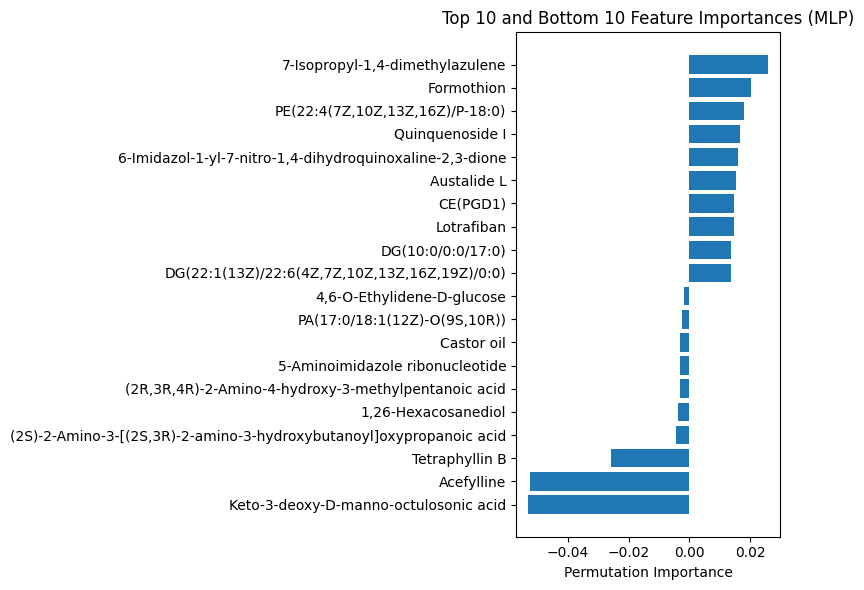

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)


importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False)

top_10 = importance_df.head(10)
bottom_10 = importance_df.tail(10)
plot_df = pd.concat([top_10, bottom_10])

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.title("Top 10 and Bottom 10 Feature Importances (MLP)")
plt.tight_layout()
plt.show()

In [ ]:
print(top_10)

                                               feature  importance
165                    7-Isopropyl-1,4-dimethylazulene    0.025926
26                                          Formothion    0.020370
101                    PE(22:4(7Z,10Z,13Z,16Z)/P-18:0)    0.017901
219                                    Quinquenoside I    0.016667
178  6-Imidazol-1-yl-7-nitro-1,4-dihydroquinoxaline...    0.016049
204                                        Austalide L    0.015432
65                                            CE(PGD1)    0.014815
143                                         Lotrafiban    0.014815
213                                  DG(10:0/0:0/17:0)    0.013580
116      DG(22:1(13Z)/22:6(4Z,7Z,10Z,13Z,16Z,19Z)/0:0)    0.013580


In [ ]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

def export_permutation_importance(
    model,
    X: pd.DataFrame,
    y,
    out_csv: str,
    scoring: str = "roc_auc",
    n_repeats: int = 30,
    random_state: int = 42,
    n_jobs: int = -1,
):
    """
    Exports permutation importance mean/std per feature to CSV.
    """
    r = permutation_importance(
        model, X, y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "perm_mean": r.importances_mean,
        "perm_std": r.importances_std
    }).sort_values("perm_mean", ascending=False)

    out["rank"] = np.arange(1, len(out) + 1)

    out.to_csv(out_csv, index=False)
    return out


In [ ]:
perm_df = export_permutation_importance(
    model=best_model,
    X=X_test,
    y=y_test,
    out_csv="perm_mlp.csv",
    scoring="roc_auc",     # or "accuracy" / "f1" etc.
    n_repeats=50
)
print(perm_df.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


                                           feature  perm_mean  perm_std  rank
165                7-Isopropyl-1,4-dimethylazulene   0.027798  0.023658     1
101                PE(22:4(7Z,10Z,13Z,16Z)/P-18:0)   0.021304  0.003043     2
65                                        CE(PGD1)   0.017602  0.009862     3
116  DG(22:1(13Z)/22:6(4Z,7Z,10Z,13Z,16Z,19Z)/0:0)   0.017391  0.008696     4
26                                      Formothion   0.017363  0.013042     5


SHAP

In [ ]:
%%capture
!pip install shap
import shap

background = X_train.sample(min(400, len(X_train)), random_state=9)
X_explain = X_test.sample(min(400, len(X_test)), random_state=42)

explainer = shap.Explainer(best_model.predict_proba, background)
shap_values = explainer(X_explain)

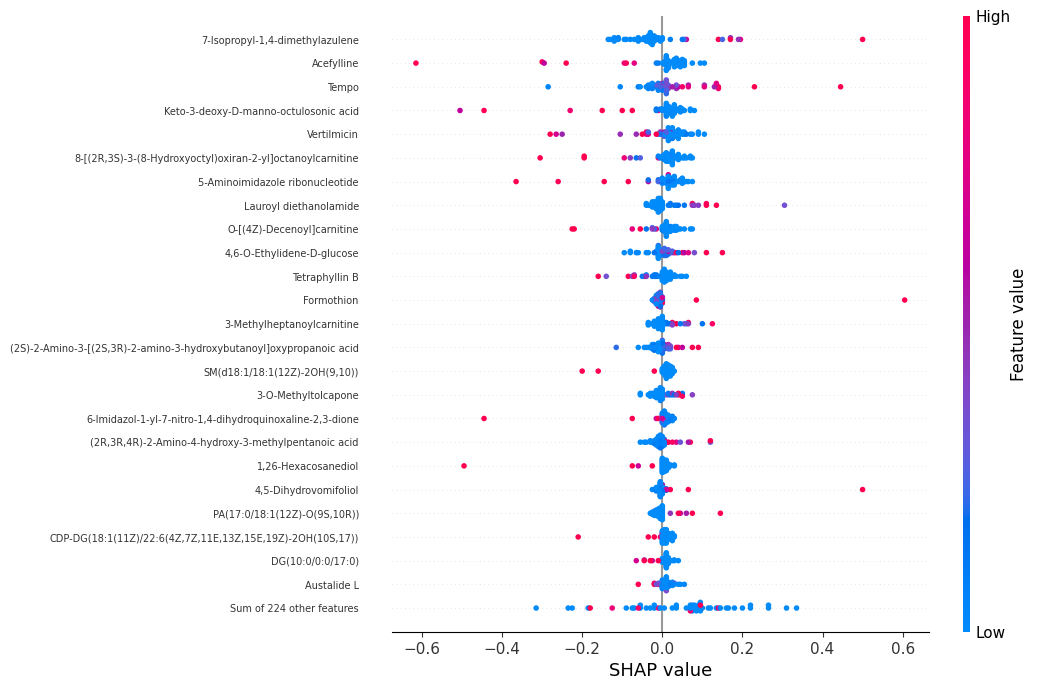

In [ ]:
shap.plots.beeswarm(
    shap_values[:, :, 1],
    max_display=25,
    plot_size=(16, 8),
    show=False
)

ax = plt.gca()
ax.set_xlabel("SHAP value")

plt.gca().tick_params(axis='y', labelsize=7)
plt.subplots_adjust(left=0.48)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import shap

""" Exports mean(|SHAP|) per feature to CSV.
    - model_predict_proba: function that accepts X (DataFrame or ndarray) and returns proba [n,2] or [n]
    - class_index: which class column to explain if output is 2D (e.g., positive class=1)
    - this is for a future analysis shown in 06_analysis
"""

def export_shap_mean_abs(
    model_predict_proba,
    X_background: pd.DataFrame,
    X_explain: pd.DataFrame,
    out_csv: str,
    class_index: int = 1,
    max_background: int = 100,
    max_explain: int = 300,
    random_state: int = 42,
):
    # sample for speed + stability
    bg = X_background.sample(min(max_background, len(X_background)), random_state=random_state)
    xe = X_explain.sample(min(max_explain, len(X_explain)), random_state=random_state)

    explainer = shap.Explainer(model_predict_proba, bg)
    shap_values = explainer(xe)

    # shap_values.values can be:
    # - (n, p) for single-output
    # - (n, p, k) for multi-class
    vals = shap_values.values
    if vals.ndim == 3:
        vals = vals[:, :, class_index]

    mean_abs = np.abs(vals).mean(axis=0)

    out = pd.DataFrame({
        "feature": xe.columns,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False)

    out["rank"] = np.arange(1, len(out) + 1)

    out.to_csv(out_csv, index=False)
    return out

In [ ]:
shap_mlp_df = export_shap_mean_abs(
    model_predict_proba=best_model.predict_proba,
    X_background=X_train,
    X_explain=X_test,
    out_csv="shap_mlp.csv",
    class_index=1
)
print(shap_mlp_df.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClass

                                   feature  mean_abs_shap  rank
225                             Acefylline       0.059907     1
165        7-Isopropyl-1,4-dimethylazulene       0.057130     2
232        5-Aminoimidazole ribonucleotide       0.052963     3
41                                   Tempo       0.052407     4
73   Keto-3-deoxy-D-manno-octulosonic acid       0.051667     5


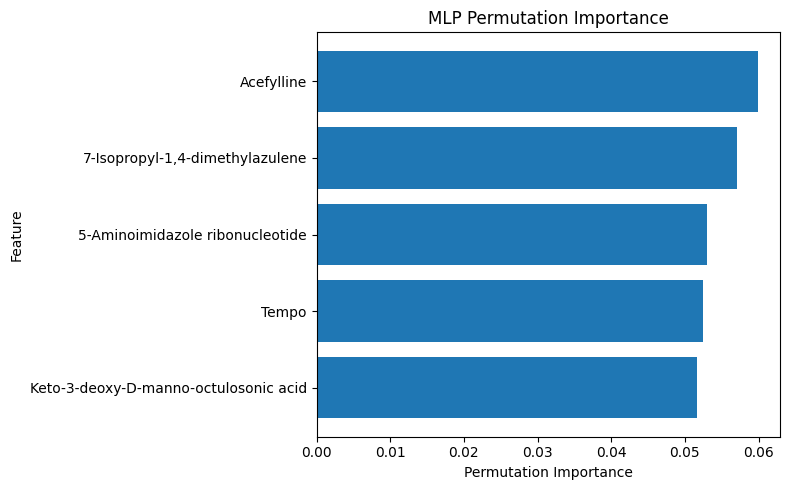

In [1]:
import matplotlib.pyplot as plt

# Data
features = [
    "Acefylline",
    "7-Isopropyl-1,4-dimethylazulene",
    "5-Aminoimidazole ribonucleotide",
    "Tempo",
    "Keto-3-deoxy-D-manno-octulosonic acid"
]

importance = [
    0.059907,
    0.057130,
    0.052963,
    0.052407,
    0.051667
]

# Plot
plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("MLP Permutation Importance")

# Optional: highest importance on top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()